# STATISTICAL ANALYSIS

## Load the data
- Here I load the pickle file that was saved in step1

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# We load the pickle file so we have the correct data type

df = pd.read_pickle('data_MPG_clean.pkl')

In [3]:
# print 10 sample values

print(df.sample(10))

           mpg  cylinders  displacement  horsepower  weight  acceleration  \
43   13.000000          8           400         170    4746     12.000000   
388  26.000000          4           156          92    2585     14.500000   
363  22.406250          6           231         110    3415     15.796875   
220  33.500000          4            85          70    1945     16.796875   
208  13.000000          8           318         150    3940     13.203125   
183  25.000000          4           116          81    2220     16.906250   
382  34.000000          4           108          70    2245     16.906250   
106  12.000000          8           350         180    4499     12.500000   
350  34.687500          4           105          63    2215     14.898438   
299  27.203125          4           141          71    3190     24.796875   

     model_year  origin  
43           71     usa  
388          82     usa  
363          81     usa  
220          77   japan  
208          76     us

In [4]:
print(df.describe())

              mpg   cylinders  displacement  horsepower       weight  \
count  392.000000  392.000000    392.000000  392.000000   392.000000   
mean    23.453125    5.471939    194.410714  104.469388  2977.584184   
std      7.804688    1.705783    104.645191   38.491160   849.402560   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.000000    4.000000    105.000000   75.000000  2225.250000   
50%     22.750000    4.000000    151.000000   93.500000  2803.500000   
75%     29.000000    8.000000    275.750000  126.000000  3614.750000   
max     46.593750    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year  
count    392.000000  392.000000  
mean      15.539062   75.979592  
std        2.757812    3.683737  
min        8.000000   70.000000  
25%       13.773438   73.000000  
50%       15.500000   76.000000  
75%       17.023438   79.000000  
max       24.796875   82.000000  


In [4]:
# lets see data types and memory usage

print(df.info(memory_usage="deep"))

<class 'pandas.core.frame.DataFrame'>
Index: 392 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   mpg           392 non-null    float16 
 1   cylinders     392 non-null    int8    
 2   displacement  392 non-null    int16   
 3   horsepower    392 non-null    int16   
 4   weight        392 non-null    int16   
 5   acceleration  392 non-null    float16 
 6   model_year    392 non-null    int8    
 7   origin        392 non-null    category
dtypes: category(1), float16(2), int16(3), int8(2)
memory usage: 8.2 KB
None


# Simple Hypothesis Testing

### One-sample t-test
- Is average MPG **significantly different from 25**?

In other words is 23.45 significantly different from 25 ?


### Hypothesis (MOST IMPORTANT)
- Null hypothesis (H₀): The true average MPG = 25
- Alternative hypothesis (H₁): The true average MPG is different from 25

This is a two-tailed test.

In [9]:
# step1: This is 1 sample. Calculate p_value

from scipy.stats import ttest_1samp

sample = df['mpg']

t_stat, p_value = ttest_1samp(sample, 25)
print(t_stat)
print(p_value)

-3.9243746184371004
0.00010272725208644043


## What the p-value actually means
### The p-value is the probability of observing a sample mean this far away from 25 (or farther) if the true mean really were 25.

In [8]:
# step2: Decide
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: Average MPG is significantly different from 25")
else:
    print("Fail to reject H₀: No significant difference from 25")

Reject H₀: Average MPG is significantly different from 25


## Two-sample t-test

Question: 
- Is average MPG of USA and Japan are different?

### Define the hypotheses (MOST IMPORTANT)
- Null hypothesis (H₀): The true average MPG of USA and Japan cars is the same.
- Alternative hypothesis (H₁): The true average MPG of USA and Japan cars is not same.

This is a two-tailed test.

In [13]:
# TODO: Remove warning
# step1: Display mean, std_dev, count for cars MPG by origin

df.groupby('origin')['mpg'].agg(['mean', 'std', 'count'])

C:\Users\hi\AppData\Local\Temp\ipykernel_5688\539353303.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('origin')['mpg'].agg(['mean', 'std', 'count'])


,mean,std,count
origin,,,
europe,27.603630,6.581332,68
japan,30.450159,6.089157,79
usa,20.033354,6.440096,245


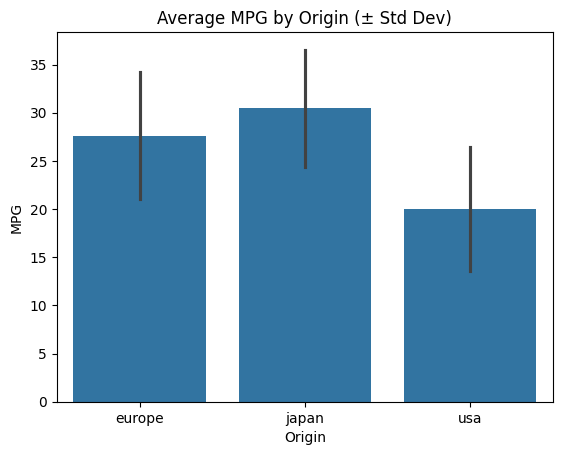

In [14]:
# step2: Let see the average of MPG of cars across origiin
sns.barplot(
    data=df,
    x="origin",
    y="mpg",
    errorbar="sd"
)

plt.title("Average MPG by Origin (± Std Dev)")
plt.ylabel("MPG")
plt.xlabel("Origin")
plt.show()

# observ: Japanese cars have high mean MPG.
# The variability , AKA STD_dev, is same for all 3 cars

In [15]:
# step3: calculate the t_stat and p_value
from scipy.stats import ttest_ind

sample_usa   = df[df['origin'] == 'usa']['mpg']
sample_japan = df[df['origin'] == 'japan']['mpg']

t_stat, p_value = ttest_ind(sample_usa, sample_japan, equal_var=False)

print(t_stat, p_value)

-13.038912700400383 7.299861600860783e-26


In [16]:
# step4: Decide
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: The true average MPG of USA and Japan cars is not the same.")
else:
    print("Fail to reject H₀: The true average MPG of USA and Japan cars statistically not different")

Reject H₀: The true average MPG of USA and Japan cars is not the same.


In [18]:
print(sample_usa.mean(), sample_japan.mean())

20.03 30.45


#### Example interpretation:
- USA mean MPG = 20.0
- Japan mean MPG = 30.0
- p-value = 0.0001
 
**Japan cars are significantly more fuel-efficient**
  

## Report
A two-sample Welch’s t-test was conducted to compare the mean MPG of cars from the USA and Japan.
The test showed a statistically significant difference in mean MPG (**p < 0.05**), with Japanese cars having higher average MPG than US cars.

# Hypothesis Testing: One-Way ANOVA

### Question:

Is the difference in average MPG across origins **statistically significant** ?


### Hypotheses
- H₀ (Null): Mean MPG is the same for all origins
- H₁ (Alt): At least one origin has a different mean MPG

### What ANOVA checks
- Between-group variance (differences between group means)
- Within-group variance (variation inside each group)


**p_value**: Probability of observing this F-statistic if the null hypothesis is true

# Add Variability (Mean + Std)

In [6]:
# TODO: Remove warning
# step1: Display mean, std_dev, count for cars MPG by origin

df.groupby('origin')['mpg'].agg(['mean', 'std', 'count'])

C:\Users\hi\AppData\Local\Temp\ipykernel_9212\214525410.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('origin')['mpg'].agg(['mean', 'std', 'count'])


,mean,std,count
origin,,,
europe,27.603630,6.581332,68
japan,30.450159,6.089157,79
usa,20.033354,6.440096,245


# Visual Support (Mean ± Variability)

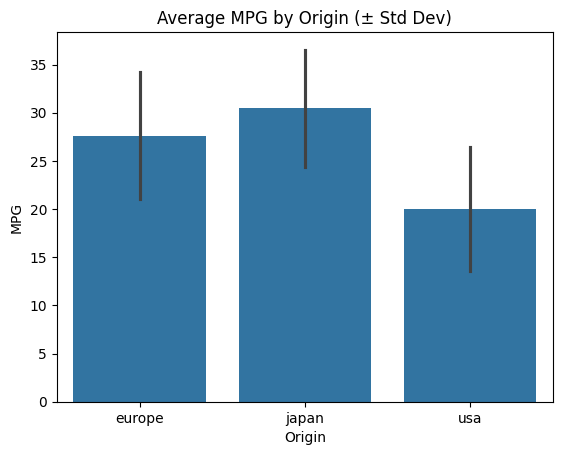

In [7]:
# step2: Show me the visual
sns.barplot(
    data=df,
    x="origin",
    y="mpg",
    errorbar="sd"
)

plt.title("Average MPG by Origin (± Std Dev)")
plt.ylabel("MPG")
plt.xlabel("Origin")
plt.show()

# observ: Japanese cars have high mean MPG.
# The variability , AKA STD_dev, is same for all 3 cars

In [33]:
# step3: compute p_value
from scipy.stats import f_oneway

usa    = df[df['origin'] == 'usa']['mpg']
europe = df[df['origin'] == 'europe']['mpg']
japan  = df[df['origin'] == 'japan']['mpg']
# print(usa)

f_stat, p_value = f_oneway(usa, europe, japan)

print(f_stat, p_value)

96.60669271682914 8.643951050960421e-35


In [9]:
# step4: Decide
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: MPG differs significantly across origins")
else:
    print("Fail to reject H₀: No significant difference in MPG")

Reject H₀: MPG differs significantly across origins


# Correlation Significance Test
### Question
- Is the relationship between **weight and MPG statistically significant** ?

### Hypotheses
- H₀ (Null): rho = 0 (no correlation)
- H₁ (Alt) : rho != 0 (there is correlation)


In [19]:
# step1: Find correlation coeff between weight and MPG. From Bivariate analysis,
# we know that it is -0.832237

columns = ['mpg', 'horsepower', 'weight', 'acceleration']
corr_matrix = df[columns].corr()
print(corr_matrix)

                   mpg  horsepower    weight  acceleration
mpg           1.000000   -0.778430 -0.832237      0.423419
horsepower   -0.778430    1.000000  0.864538     -0.689212
weight       -0.832237    0.864538  1.000000     -0.416857
acceleration  0.423419   -0.689212 -0.416857      1.000000


In [21]:
# step2: find p_value

from scipy.stats import pearsonr

stat_, p_value = pearsonr(df['weight'], df['mpg'])
print(stat_, p_value)

-0.832237422012956 6.058647373755632e-102


In [23]:
# step3: Decide
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: There is correlation")
else:
    print("Fail to reject H₀: ")

Reject H₀: There is correlation


# Variance Test

## Question
- Do USA and Japan cars have equal MPG variance?

### Hypotheses
- H₀ (Null): Variances are equal
- H₁ (Alt) : Variances are different


In [30]:
# step1: Find variance

sample_usa   = df[df['origin'] == 'usa']['mpg']
sample_japan = df[df['origin'] == 'japan']['mpg']

print("variance for usa  :", sample_usa.var())
print("variance for japan:", sample_japan.var())

variance for usa  : 41.47
variance for japan: 37.1


In [31]:
# step2: compute p-value

from scipy.stats import levene

stats_, p_value = levene(sample_usa, sample_japan)

print(stats_, p_value)

0.16331616607324553 0.6863898493616489


In [32]:
# step3: Decide
alpha = 0.05

if p_value < alpha:
    print("Reject H₀: Variance are not equal")
else:
    print("Fail to reject H₀: ")

Fail to reject H₀: 
